# 9章 IPアドレスの配布と変換

本章ではIPアドレスを動的に配布したり、インターネット接続時に変換したりする仕組みについて学習します。
IPアドレスを割り当てるプロトコルであるDHCPや、セキュリティ上も重要なアドレス変換技術であるNATを実装します。
日常生活の中で、特に自分のデバイスにIPアドレスを設定しなくてもネットワークに接続できている理由を学びます。

## DHCPによるIPアドレスの配布

### DHCPとは

DHCP（Dynamic Host Configuration Protocol）は、ネットワーク上のデバイスに対して動的にIPアドレスを割り当てるプロトコルです。
DHCPの主な目的は、ネットワーク管理者が手動で各デバイスにIPアドレスを割り当てる手間を省き、デバイスがネットワークに参加する際に自動的にIPアドレスを取得できるようにすることにあります。
要するに、デバイスのネットワーク接続プロセスを簡略化し、ネットワーク管理の効率を向上させることができます。

DHCPを使用すると、ネットワークに新しいデバイスを追加する際のIPアドレスの割り当てを自動化できます。
IPアドレス管理の手間が軽減される点が、大きなメリットだと言えます。
またDHCPにより、使用されていないIPアドレスをプールからデバイスに割り当てることができるため、IPアドレスの利用が最適化されます。
IPアドレスの手動割り当てでは、設定ミスが発生する可能性がありますが、DHCPを使用するとそのリスクを減らすことができます。
さらに一般的に、DHCPはIPアドレスだけでなく、サブネットマスク、デフォルトゲートウェイ、DNSサーバのアドレスなど、デバイスがネットワーク上で機能するために必要な追加情報も提供できます。

### DHCPの手順

DHCPの基本的な手順は以下の通りです。
IPアドレスの割り当てを担うDHCPサーバがネットワーク内に存在し、ネットワークノードはDHCPサーバに対して問い合わせを行い、IPアドレスの配布を受けます。

- DHCP Discover: ネットワークに接続されたノード（DHCPクライアント）が、IPアドレスの割り当てを要求するためにDHCP Discoverメッセージをブロードキャストします。

- DHCP Offer: DHCPサーバがこの要求を受け取り、利用可能なIPアドレスプールからIPアドレスを選択し、それを含むDHCP Offerメッセージをクライアントに送信します。

- DHCP Request: クライアントは受け取ったオファーを読み取り、そのIPアドレスを正式に要求するDHCP Requestメッセージをブロードキャストします。

- DHCP ACK: DHCPサーバは要求されたIPアドレスの割り当てを確認し、その情報を含むDHCP ACKメッセージをクライアントに送信して、IPアドレスの割り当てプロセスを完了します。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 443, done.
remote: Total 443 (delta 0), reused 0 (delta 0), pack-reused 443
Receiving objects: 100% (443/443), 116.50 KiB | 840.00 KiB/s, done.
Resolving deltas: 100% (326/326), done.


### `DHCPPacket`クラスの実装

DNSなどと同様に、`Packet`クラスをベースにして`DHCPPacket`クラスを作成します。
基本的な構造は従来のパケットと同じですが、DHCPメッセージのタイプや、追加情報を格納するための変数を持っている点がポイントです。

```
class DHCPPacket(Packet):
    # コンストラクタ
    def __init__(self, source_mac, destination_mac, source_ip, destination_ip, message_type, network_event_scheduler):
        # 親クラスのコンストラクタを呼び出し、基本的なパケット情報を初期化
        super().__init__(
            source_mac=source_mac,  # 送信元のMACアドレス
            destination_mac=destination_mac,  # 宛先のMACアドレス
            source_ip=source_ip,  # 送信元のIPアドレス
            destination_ip=destination_ip,  # 宛先のIPアドレス
            ttl=255,  # DHCPパケットはローカルネットワーク内でのみ使用されるため、TTLを最大値に設定
            fragment_flags={},  # フラグメント関連のフラグは使用しないため空の辞書を設定
            fragment_offset=0,  # フラグメントのオフセットは0に設定
            header_size=240,  # DHCPパケットのヘッダサイズは固定で240バイト
            payload_size=0,  # 実際のペイロードサイズはDHCPのオプションに依存するため0に設定
            network_event_scheduler=network_event_scheduler  # イベントスケジューラへの参照
        )
        self.message_type = message_type  # DHCPメッセージのタイプ（'DISCOVER', 'OFFER', 'REQUEST', 'ACK'）
        self.dhcp_data = {}  # DHCPメッセージに関連する追加情報を格納するための辞書

    # オブジェクトを文字列として表現する特殊メソッド
    def __str__(self):
        # mac_header辞書から送信元と宛先のMACアドレスを取得し、不明な場合は"不明"と表示
        source_mac = self.mac_header.get("source_mac", "不明")
        destination_mac = self.mac_header.get("destination_mac", "不明")
        # DHCPPacketオブジェクトの情報を文字列として返す
        return f'DHCPPacket(送信元MAC: {source_mac}, 宛先MAC: {destination_mac}, 送信元IP: {self.ip_header["source_ip"]}, 宛先IP: {self.ip_header["destination_ip"]}, Message Type: {self.message_type})'
```

### `DHCPServer`クラスの実装

`DNSServer`クラスと似た構造になるため、共通部分を新たに`Server`クラスとして定義し、それを継承する形で`DHCPServer`クラスを実装します。
`DHCPServer`クラスの基本的な構造は以下です。
IPアドレスを管理するためのプールと使用中のアドレスを記憶する変数を定義しています。

```
# Serverクラスを継承したDHCPServerクラスの定義
class DHCPServer(Server):
    # コンストラクタ
    def __init__(self, node_id, ip_address, dns_server_ip, network_event_scheduler, start_cidr, mac_address=None):
        # 親クラスのコンストラクタを呼び出し、基本的なサーバ情報を初期化
        super().__init__(node_id, ip_address, network_event_scheduler, mac_address)
        # IPアドレスプールの初期化
        self.ip_pool = self.initialize_ip_pool(start_cidr)
        # 使用中のIPアドレスを追跡するためのセット
        self.used_ips = set()
        # DNSサーバのIPアドレス
        self.dns_server_ip = dns_server_ip
        # ノードをイベントスケジューラに追加
        label = f'DHCPServer {node_id}'
        self.network_event_scheduler.add_node(node_id, label, ip_addresses=[ip_address])
```

#### IPアドレス管理

管理するIPアドレスの範囲を指定してIPアドレスプールを初期化します。
実際の割り当て時には、プールから利用可能なIPアドレスを取得し、使用済みとしてマークしていきます。

```
    # IPアドレスプールを初期化するメソッド
    def initialize_ip_pool(self, start_cidr):
        # 指定されたCIDRからネットワークを作成
        network = ip_network(start_cidr, strict=False)
        # ネットワーク内のホストアドレスをプールとしてリスト化
        ip_pool = [f"{ip}/{network.prefixlen}" for ip in network.hosts()]
        return ip_pool

    # 利用可能なIPアドレスを取得するメソッド
    def get_available_ip(self):
        # IPプールから未使用のIPアドレスを検索
        for ip in self.ip_pool:
            if ip not in self.used_ips:
                self.used_ips.add(ip)  # 使用中リストに追加
                return ip  # 利用可能なIPアドレスを返す
        return None  # 利用可能なIPアドレスがない場合はNoneを返す

    # 使用済IPアドレスを登録するメソッド
    def mark_ips_as_used(self, ips):
        for ip in ips:
            self.used_ips.add(ip)
```

#### パケット受信

DHCPのDISCOVERやREQUESTはブロードキャストされるため、ブロードキャストされてきた`DHCPPacket`に対して処理を実行します。
受け取ったパケットがDISCOVERなのか、REQUESTなのかによって異なる`DHCPPacket`を生成して返送します。

```
    # パケット受信時の処理を定義するメソッド
    def receive_packet(self, packet, received_link):
        # Serverクラスの共通処理を呼び出し
        super().receive_packet(packet, received_link)

        # ブロードキャストアドレス宛てのDHCPパケットを処理
        if packet.header["destination_mac"] == "FF:FF:FF:FF:FF:FF" and packet.header["destination_ip"] == "255.255.255.255/32":
            if isinstance(packet, DHCPPacket):
                # DHCP DISCOVERメッセージを処理
                if packet.message_type == "DISCOVER":
                    self.handle_dhcp_discover(packet)
                # DHCP REQUESTメッセージを処理
                elif packet.message_type == "REQUEST":
                    self.handle_dhcp_request(packet)
                else:
                    # その他のメッセージタイプには対応しない
                    pass

def handle_dhcp_discover(self, discover_packet):
    # DHCP DISCOVERメッセージを受け取った際の処理
    # 利用可能なIPアドレスを割り当て、DHCP OFFERメッセージを生成して送信する
    if self.ip_pool:
        assigned_ip = self.get_available_ip()  # 利用可能なIPアドレスを取得
        # DHCP OFFERメッセージの生成と送信
        offer_packet = self.create_dhcp_offer_packet(discover_packet, assigned_ip)
        # イベントスケジューラを使用してパケットの情報をログに記録
        self.network_event_scheduler.log_packet_info(offer_packet, "DHCP Offer", self.node_id)
        self._send_packet(offer_packet)  # パケットを送信

def handle_dhcp_request(self, request_packet):
    # DHCP REQUESTメッセージを受け取った際の処理
    # IPアドレスの割り当てを確定し、DHCP ACKメッセージを生成して送信する
    ack_packet = self.create_dhcp_ack_packet(request_packet)
    self._send_packet(ack_packet)  # ACKパケットを送信
```

#### `DHCPPacket`の生成

DISCOVERに対してはOFFERを、REQUESTに対してはACKを、それぞれ生成します。
基本的には、受け取ったパケットのアドレスに対して、配布するIPアドレスを指定して返送する形となります。
また、DNSサーバのIPアドレスも同時に送るようにし、ノード初期化時にDNSサーバを指定しなくても済むようにします。

```
def create_dhcp_offer_packet(self, discover_packet, offered_ip):
    # DHCP OFFERパケットの生成
    dhcp_offer_packet = DHCPPacket(
        source_mac=self.mac_address,  # DHCPサーバのMACアドレス
        destination_mac=discover_packet.header["source_mac"],  # DISCOVERメッセージを送信したクライアントのMACアドレス
        source_ip=self.ip_address,  # DHCPサーバのIPアドレス
        destination_ip=offered_ip,  # オファーするIPアドレス
        message_type="OFFER",  # メッセージタイプを"OFFER"に設定
        network_event_scheduler=self.network_event_scheduler  # イベントスケジューラ
    )
    dhcp_offer_packet.dhcp_data = {"offered_ip": offered_ip}  # オファーするIPアドレスをデータに含める
    return dhcp_offer_packet  # 生成したパケットを返す

def create_dhcp_ack_packet(self, request_packet):
    # DHCP ACKパケットの生成
    assigned_ip = request_packet.dhcp_data["requested_ip"]  # REQUESTメッセージで要求されたIPアドレス
    dhcp_ack_packet = DHCPPacket(
        source_mac=self.mac_address,  # DHCPサーバのMACアドレス
        destination_mac=request_packet.header["source_mac"],  # REQUESTメッセージを送信したクライアントのMACアドレス
        source_ip=self.ip_address,  # DHCPサーバのIPアドレス
        destination_ip=assigned_ip,  # 割り当てるIPアドレス
        message_type="ACK",  # メッセージタイプを"ACK"に設定
        network_event_scheduler=self.network_event_scheduler  # イベントスケジューラ
    )
    dhcp_ack_packet.dhcp_data = {
        "assigned_ip": assigned_ip,  # 割り当てるIPアドレス
        "dns_server_ip": self.dns_server_ip  # DNSサーバのIPアドレス
    }
    return dhcp_ack_packet  # 生成したパケットを返す
```

### `Node`クラスのアップデート

DHCPを利用できるように、`Node`クラスをアップデートします。
ここでは実装の都合上、`ip_address="192.168.1.0/24"`のようにネットワークアドレスが指定された場合に、DHCPによるIPアドレス配布を受けるように実装します。
実世界ではこのようなアドレスの設定は行いませんが、シミュレータ上では、どこのネットワークに所属させるかを明示的に表現した方が実装が容易なため、このようにしています。

#### `DHCPPacket`の送信

初期化時にIPアドレスが未設定の場合には、DISCOVERパケットを生成してブロードキャストします。
また、OFFERに対してREQUESTを行うメソッドも定義しておきます。

一つ注意点として、シミュレータの初期化時にはBPDUの交換によるトポロジ構築、リンクステートの変更などの処理が実行されます。
そういった処理が落ち着く0.5秒以降にDHCP DISCOVERを行うように設定しています。
なお、現実の装置でも似たような「間」が存在します。

```
def schedule_dhcp_packet(self):
    # ネットワークアドレスをチェックし、IPアドレスが未割り当ての場合にDHCP Discoverパケットをスケジュールする
    if self.is_network_address(self.ip_address):
        # 初期遅延をランダムに設定してDHCP Discoverをスケジュール
        initial_delay = random.uniform(0.5, 0.6)
        self.network_event_scheduler.schedule_event(
            self.network_event_scheduler.current_time + initial_delay,
            self.send_dhcp_discover
        )

def send_dhcp_discover(self):
    # DHCP Discoverパケットを生成して送信する
    dhcp_discover_packet = DHCPPacket(
        source_mac=self.mac_address,  # ソースMACアドレスはこのノードのMACアドレス
        destination_mac="FF:FF:FF:FF:FF:FF",  # 宛先MACアドレスはブロードキャストアドレス
        source_ip="0.0.0.0/32",  # ソースIPは未割り当て状態のため0.0.0.0を使用
        destination_ip="255.255.255.255/32",  # 宛先IPはブロードキャストアドレス
        message_type="DISCOVER",  # メッセージタイプはDISCOVER
        network_event_scheduler=self.network_event_scheduler  # イベントスケジューラ
    )
    # DHCP Discoverパケット送信をログに記録
    self.network_event_scheduler.log_packet_info(dhcp_discover_packet, "DHCP Discover sent", self.node_id)
    # パケットをネットワークに送信
    self._send_packet(dhcp_discover_packet)

def send_dhcp_request(self, requested_ip):
    # DHCP Requestパケットを生成して送信する
    dhcp_request_packet = DHCPPacket(
        source_mac=self.mac_address,  # ソースMACアドレスはこのノードのMACアドレス
        destination_mac="FF:FF:FF:FF:FF:FF",  # 宛先MACアドレスはブロードキャストアドレス
        source_ip="0.0.0.0/32",  # ソースIPは未割り当て状態のため0.0.0.0を使用
        destination_ip="255.255.255.255/32",  # 宛先IPはブロードキャストアドレス
        message_type="REQUEST",  # メッセージタイプはREQUEST
        network_event_scheduler=self.network_event_scheduler  # イベントスケジューラ
    )
    # OfferされたIPアドレスをリクエストする情報をdhcp_dataにセット
    dhcp_request_packet.dhcp_data = {"requested_ip": requested_ip}
    # DHCP Requestパケット送信をログに記録
    self.network_event_scheduler.log_packet_info(dhcp_request_packet, "DHCP Request sent", self.node_id)
    # パケットをネットワークに送信
    self._send_packet(dhcp_request_packet)
```

#### `DHCPPacket`の受信

ノードがDHCPサーバからOFFERメッセージを受信した場合、そのオファーされたIPアドレスを使用してREQUESTメッセージを送信します。
また、ACKメッセージを受信した場合には、そのメッセージに含まれる割り当てられたIPアドレスをノードのIPアドレスとして設定します。
さらに、DNSサーバのIPアドレスが含まれている場合にはそれも設定します。

```
def receive_packet(self, packet, received_link):

    # 省略

    if isinstance(packet, DHCPPacket):
        if packet.message_type == "OFFER":
            # DHCP Offerパケットを受信した際の処理
            self.network_event_scheduler.log_packet_info(packet, "DHCP Offer received", self.node_id)
            # OfferされたIPアドレスを取得
            offered_ip = packet.dhcp_data.get("offered_ip")
            if offered_ip:
                # OfferされたIPアドレスを使用してDHCP Requestを送信
                self.send_dhcp_request(offered_ip)
            return
        elif packet.message_type == "ACK":
            # DHCP ACKパケットを受信した際の処理
            self.network_event_scheduler.log_packet_info(packet, "DHCP ACK received", self.node_id)
            # ACKパケットから割り当てられたIPアドレスを取得
            assigned_ip = packet.dhcp_data.get("assigned_ip")
            if assigned_ip:
                # 割り当てられたIPアドレスをノードのIPアドレスとして設定
                self.ip_address = assigned_ip
                print(f"Node {self.node_id} has been assigned the IP address {assigned_ip}.")
            # ACKパケットからDNSサーバのIPアドレスを取得
            dns_server_ip = packet.dhcp_data.get("dns_server_ip")
            if dns_server_ip:
                # 割り当てられたDNSサーバのIPアドレスを設定
                self.dns_server_ip = dns_server_ip
                print(f"Node {self.node_id} has been assigned the DNS server IP address {dns_server_ip}.")
            return
```


### DHCPによるIPアドレス配布のテスト

新たに作成した`DHCPServer`を用いて、DHCPのテストを行ってみましょう。
今回はnode1に対してネットワークアドレスを設定し、IPアドレスの配布を受けるようにします。

```
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)
```

`DHCPServer`のインスタンスを宣言します。
このとき、IPアドレスプールの範囲と、DNSサーバのIPアドレスも指定しています。
DNSサーバのIPアドレスもDHCP時に通知するため、`Node`の初期化時に設定しなくて済んでいます。

```
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)
```

IPアドレスの重複配布を防ぐため、DNSサーバやスイッチ、ルータ等に対して使用済みのIPアドレスを、DHCPサーバに対して登録しておきます。

```
# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)
```

実行ログから、DHCPのパケット交換が行われ、その結果として正しくIPアドレスが配布されることを確認しましょう。


Cloning into 'network-simulator'...
remote: Enumerating objects: 815, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 815 (delta 92), reused 81 (delta 44), pack-reused 677
Receiving objects: 100% (815/815), 192.74 KiB | 3.64 MiB/s, done.
Resolving deltas: 100% (599/599), done.


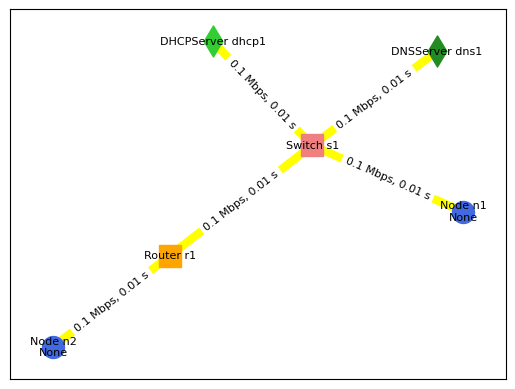

Time: 0.01 Node: r1, Event: dropped BPDU, Packet: 35d0b773-655b-428c-a9de-d719b049b506, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: dns1, Event: dropped, Packet: c0b00cca-8c51-4cbb-a4b9-7e9301e7ca09, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.012000592812582003 Node: s1, Event: received, Packet: 54d4e950-ba90-4baa-b8e1-19b5cb7cc57d, Src: 192.168.1.254, Dst: 224.0.0.5
Time: 0.0156 Node: r1, Event: dropped BPDU, Packet: a64758c1-6cd1-452c-a008-9ac5037a9e86, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: dns1, Event: dropped, Packet: a81e16de-c764-4d23-9f4f-9362eca91bfd, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0212 Node: r1, Event: dropped BPDU, Packet: f1a025c2-ffb4-4ae7-9c92-ebf388df8240, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.4463919952108951 Node: s1, Event: received, Packet: a4b0fe00-d057-4f5c-b415-f33c4616fef4, Src: 192.168.1.254/24, Dst: 224.0.0.5
Time: 0.5822448512879713 Node: n1, Event: DHCP Discover sent, Packet: 9eef68b1-7fd3-4702-bff1-a7121f73c3ec, Src: 0.0.0.0/32,

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec9a.NetworkEventScheduler import NetworkEventScheduler
from sec9a.Node import Node
from sec9a.Switch import Switch
from sec9a.Router import Router
from sec9a.Server import DNSServer, DHCPServer
from sec9a.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_url_to_ip_mapping()
router1.print_arp_table()
router1.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


## NAT

### NATとは

NAT（ネットワークアドレス変換）は、インターネットに接続されているデバイスがプライベートIPアドレスを使用して通信を行いながら、外部のネットワーク（例えばインターネット）とやり取りするために使用される技術です。
この技術は特に、家庭や企業のルータで広く使われています。

NATのメリットは、まずセキュリティの向上です。
NATを使用すると、内部ネットワークの構造やデバイスのIPアドレスが外部に漏れなくなります。
つまり内部ネットワーク上のノードが直接インターネット上からアクセスされることがなくなり、不正アクセスからネットワークを保護しやすくなります。
またインターネット上で有効なIPアドレスは限られているため、多くのノードが1つのアドレスを共有してインターネットに接続できることは、IPアドレスの節約という観点でメリットがあります。

### NATの動作

NATの動作は、基本的にはシンプルなものです。
内部から外部（インターネット）へのアウトバウンドと呼ばれる通信については、パケットの送信元アドレス（プライベートIPアドレス）が、ルータ等のNAT機能を持つノードの持つ公開IPアドレスに変換されます。
NATテーブルには、内部IPアドレスと公開IPアドレスのマッピングが記録され、通信セッションが維持されます。
逆にインターネットから内部へのインバウンド通信については、パケットがルータに到着すると、NATテーブルを参照して、適切な内部IPアドレスにパケットの宛先アドレスを変換します。

アドレス変換の方法としては以下の種類があります。

- スタティックNAT：特定の内部IPアドレスを1つの公開IPアドレスに1対1でマッピングします。これは、外部からのアクセスが必要なサーバによく使われます。

- ダイナミックNAT：内部IPアドレスを利用可能な公開IPアドレスプールから動的にマッピングします。この方法では、内部IPアドレスと公開IPアドレスの間に固定の関係はありません。

- PAT（Port Address Translation）/NAPT（Network Address Port Translation）：多くの内部IPアドレスを1つの公開IPアドレスにマッピングしますが、ポート番号を使用して各通信セッションを区別します。

なお、一般的に用いられるのはNAPT方式ですが、ポート番号はまだ扱っていないのと、アドレス変換の仕組みを理解する上ではシンプルなNATが分かり易いため、以下ではNATを実装していきます。


### `Router`クラスのアップデート

#### NATに関わる設定の追加

`Router`クラスでNATを有効化できるようにアップデートを行います。
つまりNATを有効にすると、ルータは内部ネットワークから送信される各パケットの送信元IPアドレスをexternal_ipで指定されたアドレスに変換します。
ここでは単純化のため、プライベートアドレスとして利用される`192.168.0.0/16`を内部アドレスと判断することとします。

- nat_enabled：このフラグは、ルータ上でNAT機能が有効化されているかどうかを示します。NATが有効な場合、ルータは内部ネットワークから外部ネットワークへのトラフィックに対してIPアドレスの変換を行い、逆に外部ネットワークからのトラフィックに対しても適切な内部IPアドレスへの変換を行います。

- external_ip：この属性は、外部ネットワークに対してルータが使用するIPアドレスを保持します。NATが有効な場合、このIPアドレスは内部ネットワークからのトラフィックの送信元IPアドレスとして使用されます。

- nat_table：NAT変換テーブルは、内部IPアドレスと外部IPアドレスのマッピングを記録します。このテーブルは、内部ネットワークから外部ネットワークへの通信セッションを追跡し、逆の通信が適切な内部デバイスにルーティングされることを保証するために使用されます。

```
class Router:
    def __init__(self, node_id, ip_addresses, network_event_scheduler, hello_interval=10, lsa_interval=10, default_route = None, nat_enabled=False, external_ip=None, nat_table=None):

        省略

        self.nat_enabled = nat_enabled  # NAT機能の有効/無効フラグ
        self.external_ip = external_ip  # 外部ネットワークに対応するIPアドレス（NAT有効時）
        self.nat_table = nat_table or {}  # NAT変換テーブル
```

#### NAT有効化時の処理

self.nat_enabledフラグに基づき、NATが有効化されている場合にのみNAT処理を実行します。
パケットの方向によって処理を分岐させます。

- アウトバウンド（内部→外部）：送信元IPが内部ネットワークのアドレスで、宛先IPが外部ネットワークのアドレスの場合、パケットはアウトバウンドと見なされます。この場合、送信元IPをNATを用いて外部向けのIPアドレスに変換します。

- インバウンド（外部→内部）：送信元IPが外部ネットワークのアドレスで、宛先IPが内部ネットワークのアドレスの場合、パケットはインバウンドと見なされます。この場合、宛先IPをNATテーブルに基づいて内部ネットワークの適切なIPアドレスに変換します。

```
    def process_and_enqueue_packet(self, packet, link):
        # NATが有効な場合に限り処理を行う
        if self.nat_enabled:
            source_internal = self.is_internal_ip(packet.header["source_ip"])
            destination_internal = self.is_internal_ip(packet.header["destination_ip"])

            if source_internal and not destination_internal:
                # 内部ネットワークから外部ネットワークへのパケット（outbound）
                self.apply_nat(packet, 'outbound')
            elif not source_internal and destination_internal:
                # 外部ネットワークから内部ネットワークへのパケット（inbound）
                self.apply_nat(packet, 'inbound')
```

#### アドレス変換

- 内部IPアドレスの判断: is_internal_ipメソッドは、指定されたIPアドレスが内部ネットワーク（`192.168.0.0/16`）に属しているかどうかを判断します。CIDR表記からIPアドレス部分を抽出し、指定されたネットワーク内に存在するかを確認します。

- NATの適用: apply_natメソッドは、パケットの送信方向（内部から外部へのアウトバウンド、外部から内部へのインバウンド）に基づいてNAT処理を適用します。NATが有効な場合、このメソッドはパケットの送信元または宛先IPアドレスを適切に変換します。

```
    def is_internal_ip(self, ip_address):
        # CIDRネットワーク表記からIPアドレス部分のみを抽出
        ip_address = ip_address.split('/')[0]  # CIDR表記を分割し、IPアドレス部分を取得
        internal_network = ipaddress.ip_network('192.168.0.0/16', strict=False)
        return ipaddress.ip_address(ip_address) in internal_network

    def apply_nat(self, packet, direction):
        if self.network_event_scheduler.nat_verbose:
            original_ip = packet.header["source_ip"] if direction == 'outbound' else packet.header["destination_ip"]
            new_ip = self.external_ip if direction == 'outbound' else self.nat_table.get(packet.header["destination_ip"], "未変換")

            log_message = f"NAT {direction}: {original_ip} -> {new_ip}"
            self.network_event_scheduler.log_packet_info(packet, log_message, self.node_id)

        if direction == 'outbound':
            # 外部ネットワークへのパケット送信時のNAT処理
            original_src_ip = packet.header["source_ip"]
            # 変換テーブルに登録し、パケットの送信元IPを外部IPに変更
            self.nat_table[original_src_ip] = self.external_ip
            packet.header["source_ip"] = self.external_ip
        elif direction == 'inbound':
            # 外部ネットワークからのパケット受信時のNAT処理
            original_dst_ip = packet.header["destination_ip"]
            # 変換テーブルを参照し、パケットの宛先IPを内部ネットワークのIPに変更
            internal_ip = self.nat_table.get(original_dst_ip)
            if internal_ip:
                packet.header["destination_ip"] = internal_ip
```


### NATによるアドレス変換のテスト

アップデートした`Router`クラスを用いて、NATによるアドレス変換のテストを行ってみましょう。
ルータのインスタンス作成時に、以下のように記述します。

```
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.0.0.1/24"], network_event_scheduler=nes, nat_enabled=True, external_ip="10.0.0.1")
```

また、NetworkEventSchedulerに`nat_verbose=True`というオプションを指定することで、アドレス変換のログも出力して確認することができます。

```
nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False, nat_verbose=True)
```

シミュレーション終了後には、NATテーブルを出力して、どのようにアドレス変換が行われたか確認できます。

```
router1.print_nat_table()
```


Cloning into 'network-simulator'...
remote: Enumerating objects: 845, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 845 (delta 116), reused 94 (delta 51), pack-reused 677
Receiving objects: 100% (845/845), 189.17 KiB | 4.98 MiB/s, done.
Resolving deltas: 100% (623/623), done.


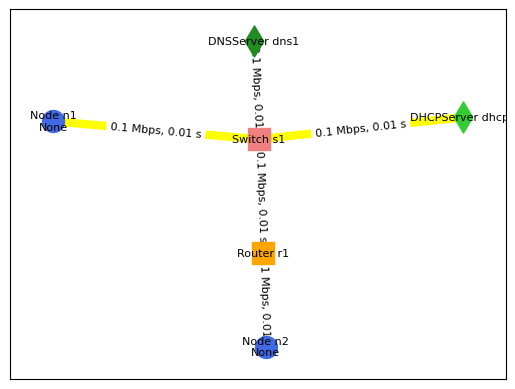

Time: 0.01 Node: r1, Event: dropped BPDU, Packet: d4a7e731-15b9-42a0-9d97-a97867c489b0, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.01 Node: dns1, Event: dropped, Packet: b2d39013-aa62-43da-9def-a215650423b3, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: r1, Event: dropped BPDU, Packet: 0b27ec8e-1aaa-461f-aeeb-9a76a2d1eb6c, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0156 Node: dns1, Event: dropped, Packet: 169bfd07-ae9a-4217-9e7e-aaebae9f7a8f, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.0212 Node: r1, Event: dropped BPDU, Packet: 2bf5e9d9-026b-495a-af6f-e0258701fd72, Src: 0.0.0.0/24, Dst: 0.0.0.0/24
Time: 0.053337176801622505 Node: s1, Event: received, Packet: 3cbad77a-5d65-4b8c-bcc6-d2baa34b2456, Src: 192.168.1.254, Dst: 224.0.0.5
Time: 0.46363925436340175 Node: s1, Event: received, Packet: 5e5f52e3-857d-4ea0-8980-d1d6e8e3650d, Src: 192.168.1.254/24, Dst: 224.0.0.5
Time: 0.546133768093593 Node: n1, Event: DHCP Discover sent, Packet: a48917a8-5d0b-4521-981b-ff87cb45b77e, Src: 0.0.0.0/32,

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec9b.NetworkEventScheduler import NetworkEventScheduler
from sec9b.Node import Node
from sec9b.Switch import Switch
from sec9b.Router import Router
from sec9b.Server import DNSServer, DHCPServer
from sec9b.Link import Link

nes = NetworkEventScheduler(log_enabled=True, verbose=True, routing_verbose=False, nat_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)
node2 = Node(node_id="n2", ip_address="10.0.0.2/24", network_event_scheduler=nes)
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "10.0.0.1/24"], network_event_scheduler=nes, nat_enabled=True, external_ip="10.0.0.1")
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "10.0.0.2/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_traffic(destination_url="www.example.com", bitrate=10000, start_time=1.0, duration=2.0, header_size=50, payload_size=10000, burstiness=1.0)

# イベントスケジューラを実行
nes.run_until(5.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_url_to_ip_mapping()
router1.print_nat_table()
router1.print_arp_table()
router1.print_routing_table()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)


### 演習課題1: DHCPによるアドレス配布

#### 目的
DHCPによるIPアドレス配布の手順をトレースし、その仕組みを理解する。

#### 課題
5つ以上の`Node`に対してDHCPによりIPアドレスを設定してみましょう。
そしてNetworkEventSchedulerのログから、DHCP関連のログを抽出し、まとめてみましょう。

### 演習課題2: NATによるアドレス変換

#### 目的
NATによるIPアドレス変換の手順をトレースし、その仕組みを理解する。

#### 課題
5つ以上の`Node`を用いて、NATによるアドレス変換をシミュレーションしてみましょう。
そしてNetworkEventSchedulerのログから、NAT関連のログを抽出し、まとめてみましょう。


## 本章のまとめ

本章では、IPアドレスを動的に配布するDHCPと、インターネット接続時に変換するNATについて学習しました。
DHCPにより、利用可能なIPアドレスがDHCPサーバから配信され、それを設定して通信を開始することができます。
またNATにより、プライベートアドレスからグローバルアドレスへの変換を行い、セキュリティ向上などに寄与します。
このような仕組みがあるおかげで、ネットワークに接続する度にIPアドレスを自分で設定せずとも済んでいるのです。
